# 04 — Feature Engineering

This notebook builds the modeling dataset for **Engagement Prediction**: the target
(`engagement_level`) and the feature set that will be used to train the three models in
notebook 05.

The single most important rule here is **avoiding data leakage**: a feature is only usable
if a content creator would actually know it *before* publishing the post.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Month'] = df['Timestamp'].dt.month
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns (+ derived Month as int 1-12).")


Loaded 5000 rows, 21 columns (+ derived Month as int 1-12).


## 1. Classifying every column

| Column | Role | Reasoning |
|---|---|---|
| Platform | Input feature | Known before publishing (user selects it) |
| Content_Type | Input feature | Known before publishing (user selects it) |
| Category | Input feature | Known before publishing (user selects it) |
| Hour_of_Day | Input feature | Known before publishing (user plans it) |
| Day_of_Week | Input feature | Known before publishing (user plans it) |
| Month | Input feature | Known before publishing (derived from planned date) |
| Hashtag_Count | Input feature | User decides how many hashtags to use before posting |
| Content_Length | Input feature | User controls caption/content length before posting |
| Sentiment | Input feature | Represents the *planned* tone of the content (chosen pre-publish) |
| Influencer_Tier | Input feature | Derived from Follower_Count, known before publishing |
| Follower_Count | Input feature | Known before publishing (account attribute) |
| Has_Media | Input feature | User decides before publishing whether to attach media |
| Is_Verified | Input feature | Fixed account attribute, known before publishing |
| **Engagement_Rate** | **Target source** | Used only to derive `engagement_level` |
| Likes | Excluded — data leakage | Only known AFTER publishing |
| Comments | Excluded — data leakage | Only known AFTER publishing |
| Shares | Excluded — data leakage | Only known AFTER publishing |
| Views | Excluded — data leakage | Only known AFTER publishing |
| Saves | Excluded — data leakage | Only known AFTER publishing |
| Flag_Engagement_Above_Views | Excluded — data leakage | Computed FROM post-performance columns |
| Flag_Engagement_Rate_Outlier | Excluded — data leakage | Computed FROM Engagement_Rate itself |
| Post_ID | Excluded — identifier | Not predictive, just a row ID |
| Timestamp | Excluded — replaced | Already decomposed into Hour_of_Day / Day_of_Week / Month |

**Important caveat about `Sentiment`:** the dataset has no actual caption text, so we cannot
verify whether `Sentiment` reflects a *planned* tone or was labeled by analyzing the
published caption after the fact. We treat it as a pre-publication planning input (the
user selects an intended tone), and flag this assumption explicitly in **Dataset
Limitations** at the end of the project.

In [2]:
LEAKAGE_COLUMNS = ['Likes', 'Comments', 'Shares', 'Views', 'Saves',
                    'Flag_Engagement_Above_Views', 'Flag_Engagement_Rate_Outlier']
IDENTIFIER_COLUMNS = ['Post_ID', 'Timestamp']
TARGET_SOURCE = 'Engagement_Rate'

INPUT_FEATURES = ['Platform', 'Content_Type', 'Category', 'Hour_of_Day', 'Day_of_Week',
                   'Month', 'Hashtag_Count', 'Content_Length', 'Sentiment',
                   'Influencer_Tier', 'Follower_Count', 'Has_Media', 'Is_Verified']

assert set(INPUT_FEATURES) & set(LEAKAGE_COLUMNS) == set(), "Leakage column found in features!"
print("Input features (", len(INPUT_FEATURES), "):", INPUT_FEATURES)
print("\nExcluded as data leakage:", LEAKAGE_COLUMNS)
print("Excluded as identifiers:", IDENTIFIER_COLUMNS)


Input features ( 13 ): ['Platform', 'Content_Type', 'Category', 'Hour_of_Day', 'Day_of_Week', 'Month', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Follower_Count', 'Has_Media', 'Is_Verified']

Excluded as data leakage: ['Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Flag_Engagement_Above_Views', 'Flag_Engagement_Rate_Outlier']
Excluded as identifiers: ['Post_ID', 'Timestamp']


## 2. Defining the target: `engagement_level`



In [3]:
er = df['Engagement_Rate']
q33, q67 = er.quantile(1/3), er.quantile(2/3)
print(f"33rd percentile: {q33:.2f}")
print(f"67th percentile: {q67:.2f}")

def label_engagement(x):
    if x <= q33:
        return 'Low'
    elif x <= q67:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['Engagement_Rate'].apply(label_engagement)
class_counts = df['engagement_level'].value_counts()
print()
print(class_counts)
print()
print((class_counts / len(df) * 100).round(1).astype(str) + '%')


33rd percentile: 1.37
67th percentile: 4.23

engagement_level
Medium    1669
Low       1669
High      1662
Name: count, dtype: int64

engagement_level
Medium    33.4%
Low       33.4%
High      33.2%
Name: count, dtype: str


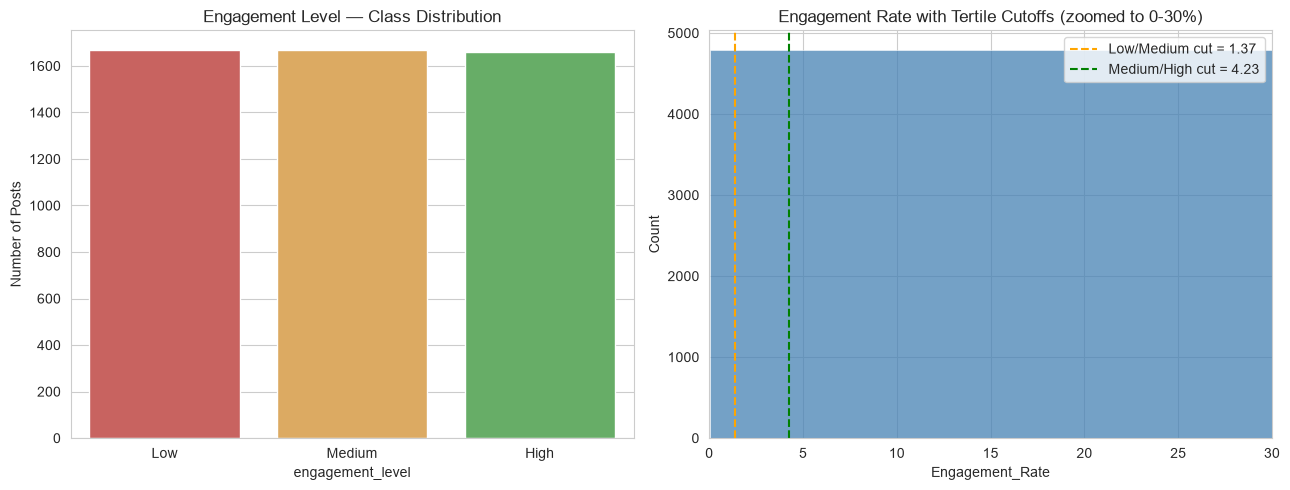

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='engagement_level', hue='engagement_level', order=order, ax=axes[0],
              palette={'Low': '#d9534f', 'Medium': '#f0ad4e', 'High': '#5cb85c'}, legend=False)
axes[0].set_title('Engagement Level — Class Distribution')
axes[0].set_ylabel('Number of Posts')

sns.histplot(er, bins=80, ax=axes[1], color='steelblue')
axes[1].axvline(q33, color='orange', linestyle='--', label=f'Low/Medium cut = {q33:.2f}')
axes[1].axvline(q67, color='green', linestyle='--', label=f'Medium/High cut = {q67:.2f}')
axes[1].set_xlim(0, 30)  # zoom in, most of the mass is here
axes[1].set_title('Engagement Rate with Tertile Cutoffs (zoomed to 0-30%)')
axes[1].legend()
plt.tight_layout()
plt.show()


**How each class was defined:**
- **Low** = Engagement_Rate at or below the 33rd percentile
- **Medium** = Engagement_Rate between the 33rd and 67th percentile
- **High** = Engagement_Rate above the 67th percentile

**Class balance:** by construction, the three classes are almost perfectly balanced
(~33% each), which is good for classification — we won't need heavy class-imbalance
correction, though we still report macro F1 and per-class metrics in notebook 06 to be sure.

## 3. Encoding categorical features
We don't hard-encode here — encoding is done inside an sklearn `Pipeline` in notebook 05 so that no information leaks from the test set into training. Here we just confirm the categorical vs numerical split.

In [5]:
categorical_features = ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier']
boolean_features = ['Has_Media', 'Is_Verified']
numerical_features = ['Hour_of_Day', 'Month', 'Hashtag_Count', 'Content_Length', 'Follower_Count']

print("Categorical features (-> one-hot encoding):", categorical_features)
print("Boolean features (-> treated as 0/1):", boolean_features)
print("Numerical features (-> scaled for Logistic Regression only):", numerical_features)

assert set(categorical_features + boolean_features + numerical_features) == set(INPUT_FEATURES)
print("\nAll input features accounted for.")


Categorical features (-> one-hot encoding): ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier']
Boolean features (-> treated as 0/1): ['Has_Media', 'Is_Verified']
Numerical features (-> scaled for Logistic Regression only): ['Hour_of_Day', 'Month', 'Hashtag_Count', 'Content_Length', 'Follower_Count']

All input features accounted for.


## 4. Quick sanity check: do features actually vary with the target?
Before training anything, a quick check that at least some signal exists.

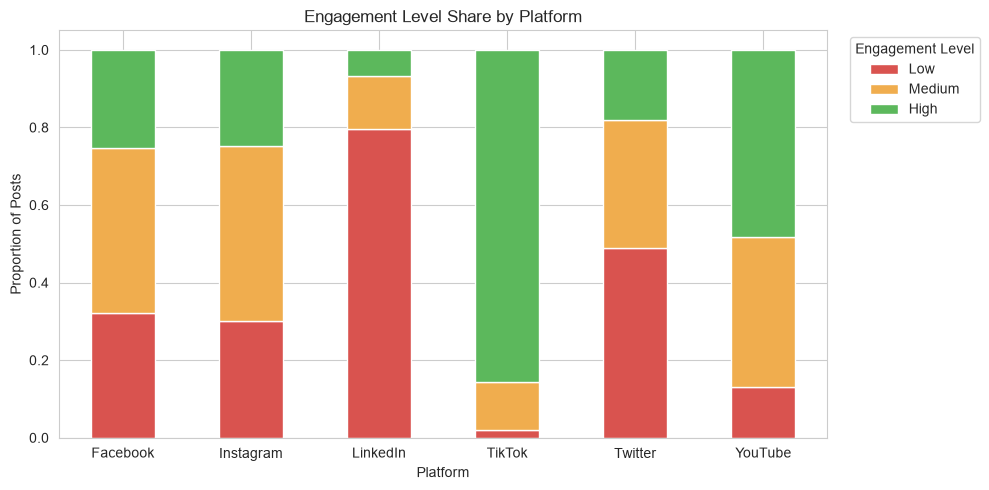

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
platform_level = pd.crosstab(df['Platform'], df['engagement_level'], normalize='index')[order]
platform_level.plot(kind='bar', stacked=True, ax=ax,
                     color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax.set_title('Engagement Level Share by Platform')
ax.set_ylabel('Proportion of Posts')
ax.legend(title='Engagement Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
print("Numerical feature correlation with Engagement_Rate (informal signal check):")
for col in numerical_features:
    print(f"  {col}: {df[col].corr(df['Engagement_Rate']):.3f}")
print()
print("NOTE: these correlations are weak across the board, which is an honest signal that")
print("this dataset may have a limited predictive relationship between pre-publish features")
print("and engagement outcome. We carry this caveat into model evaluation (notebook 06) and")
print("do not inflate expectations of model performance.")


Numerical feature correlation with Engagement_Rate (informal signal check):
  Hour_of_Day: -0.007
  Month: 0.014
  Hashtag_Count: -0.006
  Content_Length: -0.065
  Follower_Count: -0.205

NOTE: these correlations are weak across the board, which is an honest signal that
this dataset may have a limited predictive relationship between pre-publish features
and engagement outcome. We carry this caveat into model evaluation (notebook 06) and
do not inflate expectations of model performance.


## 5. Save the feature-engineered dataset

In [8]:
FINAL_COLUMNS = INPUT_FEATURES + ['engagement_level', 'Engagement_Rate']
model_df = df[FINAL_COLUMNS].copy()

import os
os.makedirs('../data/processed', exist_ok=True)
OUT_PATH = '../data/processed/model_ready_dataset.csv'
model_df.to_csv(OUT_PATH, index=False)
print(f"Saved {model_df.shape[0]} rows x {model_df.shape[1]} columns to {OUT_PATH}")
model_df.head()


Saved 5000 rows x 15 columns to ../data/processed/model_ready_dataset.csv


,Platform,Content_Type,Category,Hour_of_Day,Day_of_Week,Month,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Follower_Count,Has_Media,Is_Verified,engagement_level,Engagement_Rate
0,Instagram,Carousel,Business,1,Monday,1,16,985,Positive,Macro,223080,True,False,Medium,3.85
1,LinkedIn,Document,Health,5,Monday,1,9,627,Negative,Macro,312647,False,True,Low,0.63
2,Instagram,Carousel,Food,9,Monday,1,27,79,Positive,Macro,220737,True,True,Low,0.78
3,Facebook,Video,Sports,10,Monday,1,17,554,Neutral,Macro,428935,True,False,Low,0.27
4,Instagram,Photo,Fitness,13,Monday,1,5,1136,Positive,Mid-tier,64384,True,False,High,15.31


## Summary of Notebook 04

- **Target**: `engagement_level` (Low / Medium / High), created from `Engagement_Rate`
  using **tertile (33rd/67th percentile) cutoffs** — chosen because the raw distribution
  is heavily right-skewed with real outliers, so fixed thresholds would have produced
  badly imbalanced classes.
- **13 input features** selected, all confirmed to be knowable *before* publishing.
- **7 columns excluded as data leakage** (Likes, Comments, Shares, Views, Saves, and the
  two flag columns derived from them), plus Post_ID/Timestamp as identifiers.
- Correlations between individual numerical features and engagement are weak — this is
  flagged honestly and carried forward, rather than hidden.
- Output saved to `data/processed/model_ready_dataset.csv`, used directly by notebook 05.

Next: `05_model_training.ipynb`.